<a href="https://colab.research.google.com/github/Anisca-hub/TechDiva-s_AIML_Horizon26/blob/main/TechDiva's%20ML%20Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Random Forest Accuracy: 50.50%


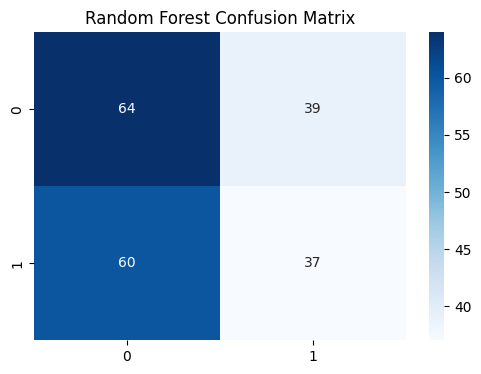

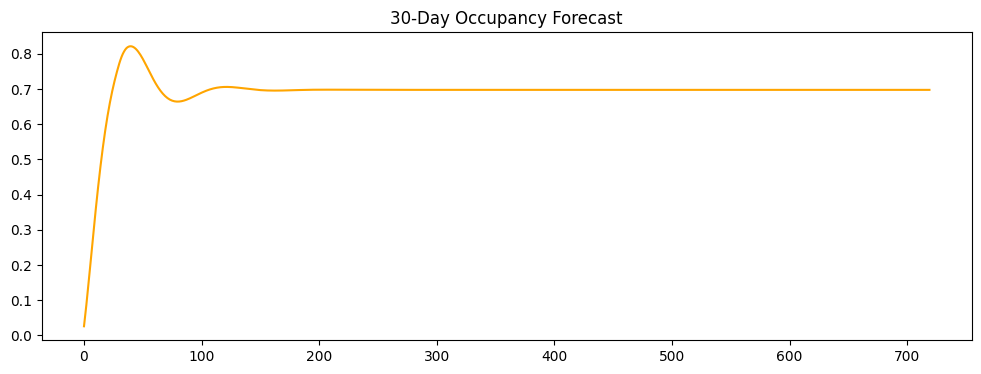

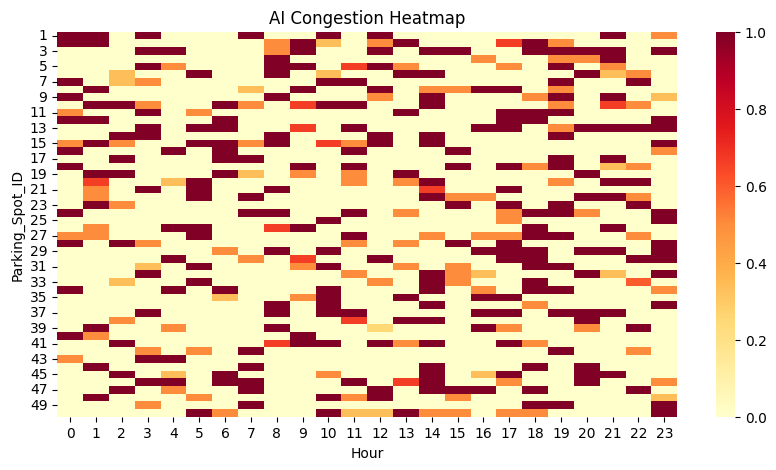

/tmp/ipykernel_735/2147741447.py:93: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=co2_by_vehicle, x='Vehicle_Type', y='CO2_Emissions', palette='viridis')


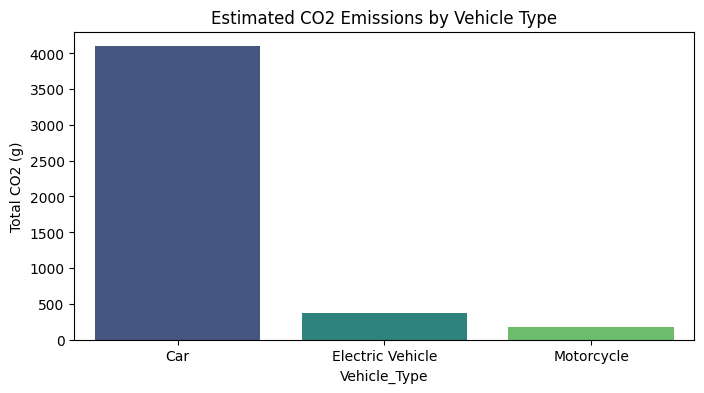


Recommended Dynamic Parking Price: $14.50
Average CO2 Emission per Session: 4.65g
Smart Recommendation: Availability is good.

--- Decoded Trip History & Sustainability ---


,Timestamp,Vehicle_Type,User_Type,Parking_Duration,CO2_Emissions
0,2021-01-01 00:00:00.000000000,Car,Visitor,4,8.000000
1,2021-01-02 06:39:16.756756756,Car,Registered,3,6.000000
2,2021-01-03 13:18:33.513513513,Car,Registered,5,10.000000
3,2021-01-04 19:57:50.270270270,Motorcycle,Visitor,2,0.666667
4,2021-01-06 02:37:07.027027027,Car,Visitor,2,4.000000
5,2021-01-07 09:16:23.783783783,Car,Registered,1,2.000000
6,2021-01-08 15:55:40.540540540,Electric Vehicle,Registered,5,6.666667
7,2021-01-09 22:34:57.297297297,Car,Registered,4,8.000000
8,2021-01-11 05:14:14.054054054,Electric Vehicle,Registered,3,4.000000
9,2021-01-12 11:53:30.810810810,Electric Vehicle,Staff,5,6.666667


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

# 1. Load Dataset
csv_path = '/content/IIoT_Smart_Parking_Management.csv'
data = pd.read_csv(csv_path)

# 2. Preprocessing & Timestamp Handling
target_col = 'Occupancy_Status'
time_col = 'Timestamp'
data[time_col] = pd.to_datetime(data[time_col], errors='coerce')
data = data.dropna(subset=[time_col])

# 3. Encoding Categorical Features and Target
le_dict = {}
cat_features = ['Vehicle_Type', 'User_Type', 'Weather', 'Nearby_Traffic_Level', 'Payment_Status', 'Parking_Violation', 'Reserved_Status', target_col]
for col in cat_features:
    if col in data.columns:
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col].astype(str))
        le_dict[col] = le

# 4. Random Forest Prediction
features = [f for f in ['Vehicle_Type', 'User_Type', 'Sensor_Reading_Proximity', 'Sensor_Reading_Pressure', 'Pressure', 'Temperature', 'Precipitation', 'Nearby_Traffic_Level', 'Reserved_Status', 'Electric_Vehicle'] if f in data.columns]
X_rf = data[features].fillna(0)
y_rf = data[target_col]
X_train, X_test, y_train, y_test = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print(f'Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf)*100:.2f}%')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.show()

# 5. LSTM Hourly and Next Month Forecast
hourly_occ_df = data.set_index(time_col)[target_col].resample('h').mean().ffill().fillna(0)
hourly_occ = hourly_occ_df.values.reshape(-1, 1)
scaler = MinMaxScaler()
scaled_occ = scaler.fit_transform(hourly_occ)
seq_length = 24
X_seq, y_seq = [], []
for i in range(len(scaled_occ) - seq_length):
    X_seq.append(scaled_occ[i:i+seq_length])
    y_seq.append(scaled_occ[i+seq_length])
X_seq, y_seq = np.array(X_seq), np.array(y_seq)
lstm_model = Sequential([Input(shape=(seq_length, 1)), LSTM(50, activation='relu'), Dense(1)])
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_seq[:int(0.8*len(X_seq))], y_seq[:int(0.8*len(X_seq))], epochs=5, batch_size=16, verbose=0)

# Recursive 30-Day Forecast
last_sequence = scaled_occ[-seq_length:]
future_preds = []
for _ in range(24 * 30):
    next_val = lstm_model.predict(last_sequence.reshape(1, seq_length, 1), verbose=0)
    future_preds.append(next_val[0, 0])
    last_sequence = np.append(last_sequence[1:], next_val)

plt.figure(figsize=(12, 4))
plt.plot(scaler.inverse_transform(np.array(future_preds).reshape(-1, 1)), color='orange')
plt.title('30-Day Occupancy Forecast')
plt.show()

# 6. Heatmap & Dynamic Recommendation
data['Hour'] = data[time_col].dt.hour
pivot_df = data.pivot_table(index='Parking_Spot_ID', columns='Hour', values=target_col, aggfunc='mean').fillna(0)
plt.figure(figsize=(10, 5))
sns.heatmap(pivot_df, cmap='YlOrRd')
plt.title('AI Congestion Heatmap')
plt.show()

# 7. Sustainability (CO2) & Dynamic Pricing
co2_map = {0: 120, 1: 80, 2: 20}
data['CO2_Emissions'] = data['Vehicle_Type'].map(co2_map).fillna(0) * (data.get('Parking_Duration', 60) / 60)
dynamic_price = 10.0 * (1 + data[target_col].mean())

# CO2 Prediction Visualization
plt.figure(figsize=(8, 4))
co2_by_vehicle = data.groupby('Vehicle_Type')['CO2_Emissions'].sum().reset_index()
co2_by_vehicle['Vehicle_Type'] = le_dict['Vehicle_Type'].inverse_transform(co2_by_vehicle['Vehicle_Type'])
sns.barplot(data=co2_by_vehicle, x='Vehicle_Type', y='CO2_Emissions', palette='viridis')
plt.title('Estimated CO2 Emissions by Vehicle Type')
plt.ylabel('Total CO2 (g)')
plt.show()

print(f'\nRecommended Dynamic Parking Price: ${dynamic_price:.2f}')
print(f'Average CO2 Emission per Session: {data["CO2_Emissions"].mean():.2f}g')

if future_preds[0] > 0.7: print('Smart Recommendation: High occupancy expected. Leave early!')
else: print('Smart Recommendation: Availability is good.')

print("\n--- Decoded Trip History & Sustainability ---")
history = data[['Timestamp', 'Vehicle_Type', 'User_Type', 'Parking_Duration', 'CO2_Emissions']].head(10).copy()
history['Vehicle_Type'] = le_dict['Vehicle_Type'].inverse_transform(history['Vehicle_Type'])
history['User_Type'] = le_dict['User_Type'].inverse_transform(history['User_Type'])
display(history)